In [21]:
import json
import csv
import urllib.request
import urllib.parse
import xml.etree.ElementTree as ET
from pprint import pprint
from pathlib import Path
from collections import Counter
from statistics import mean, median
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Directorio raíz del proyecto (un nivel arriba de notebooks/)
ROOT = Path("..").resolve()
print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: /home/diego/arxiv_classifier


## Sección 1 — El problema

### 1.1 Motivación y formulación del problema

arXiv es el repositorio de preprints científicos más grande del mundo: más de 2.3 millones de artículos de física, matemáticas, ciencias de la computación, biología cuantitativa y más, todos de acceso abierto.

**El problema:** dado el abstract de un artículo de la sección `cs.*` (Computer Science), determinar a cuál de 10 subcategorías pertenece.

Formulación formal:
- **Entrada:** texto del abstract (≈100–400 palabras)
- **Salida:** una etiqueta de clase ∈ {cs.AI, cs.CL, cs.CV, cs.CR, cs.DB, cs.IR, cs.LG, cs.NE, cs.RO, cs.SE}
- **Tipo de tarea:** clasificación multiclase, texto corto, etiquetas ruidosas

**Por qué "etiquetas ruidosas":** las categorías en arXiv las asignan los propios autores libremente. Un paper de aprendizaje automático puede etiquetarse como cs.AI, cs.LG o cs.NE según la comunidad desde la que escribe el autor — no existe una respuesta objetivamente correcta. Las etiquetas que usamos como *ground truth* reflejan decisiones subjetivas.

### 1.2 Por qué este problema es valioso como caso de estudio

Este proyecto tiene todas las propiedades que hacen difícil el ML en producción:

| Propiedad | Lo que implica |
|-----------|----------------|
| **Datos reales desde cero** | Hay que interactuar con una API externa, manejar errores de red, decidir qué guardar |
| **Etiquetas ruidosas por naturaleza** | No hay respuesta objetiva; el modelo aprende patrones estadísticos sobre decisiones humanas subjetivas |
| **Solapamiento semántico real** | cs.AI, cs.LG y cs.NE son genuinamente similares; los errores del modelo serán *razonables*, no aleatorios |
| **Pipeline completo visible** | Desde la API hasta la predicción, cada etapa tiene código que se puede leer y modificar |

Un proyecto que empieza con datos limpios de Kaggle enseña ML. Un proyecto como éste enseña *cómo se hace ML* en la práctica.

> **Punto clave para recordar:** el problema no es difícil por ser un didáctico, es difícil porque las clases se solapan semánticamente igual que en el mundo real. Los errores del modelo revelarán algo verdadero sobre cómo los investigadores organizan el conocimiento.

## Sección 2 — Arquitectura del pipeline

### 2.1 Las 8 etapas del pipeline

El proyecto sigue un pipeline lineal donde cada etapa tiene una entrada definida, una salida en disco, y un criterio de aceptación antes de pasar a la siguiente.

| Etapa | Nombre | Entrada | Salida |
|-------|--------|---------|--------|
| 1 | **Exploración de categorías** | Lista de candidatos | `data/results/categories_stats.json` |
| 2 | **Selección de categorías** | Stats de exploración | `configs/categories.json` |
| 3 | **Recolección de metadata** | `categories.json` | `data/raw/metadata.json` |
| 4 | **Descarga de PDFs** | `metadata.json` | `data/pdfs/<cat>/<id>.pdf` |
| 5 | **Extracción de texto** | PDFs | `data/interim/extracted_*.json` |
| 6 | **Selección de estrategia** | Textos extraídos | `data/interim/extracted.json` + embeddings |
| 7 | **Construcción del dataset** | Embeddings | splits train / val / test |
| 8 | **Entrenamiento y evaluación** | Dataset | modelo + métricas por clase |

Cada etapa tiene un script en `src/` que puede ejecutarse de forma independiente.

### 2.2 Flujo de datos

```
[API arXiv]
    │
    ├─ 1. Exploración ─────────────► categories_stats.json
    │                                         │
    └─ 2. Selección (decisión manual) ──► categories.json
                                              │
         3. Recolección de metadata ──────► metadata.json   (2 000 artículos)
                                              │
         4. Descarga de PDFs ─────────────► data/pdfs/      (2 000 archivos)
                                              │
         5. Extracción de texto ──────────► extracted_pymupdf.json
                                              extracted_docling.json
                                              │
         6. Selección de estrategia ──────► extracted.json + embeddings/
                                              │
         7. Construcción del dataset ─────► train / val / test
                                              │
         8. Entrenamiento y evaluación ───► modelo + métricas
```

### 2.3 Decisiones de diseño previas al código

Antes de escribir la primera línea se tomaron estas decisiones explícitas:

**¿Cuántos artículos por clase?** 200. Suficiente para entrenar un clasificador simple con embeddings pre-entrenados, pero manejable sin infraestructura especial. Con 10 clases → 2 000 artículos en total.

**¿Qué texto se clasifica?** El abstract, no el PDF completo. Los abstracts son uniformes en estructura, están disponibles directamente de la API, y concentran la información semántica relevante para la clasificación.

**¿Cómo elegir la librería de extracción de PDFs?** Comparar dos estrategias (PyMuPDF y Docling) midiendo su similitud coseno con el abstract oficial de la API. Esto evita elegir arbitrariamente una librería sin datos.

**¿Qué tipo de modelo?** Un clasificador sobre embeddings pre-entrenados (`all-MiniLM-L6-v2`). Evita entrenar desde cero un modelo de lenguaje, que requeriría órdenes de magnitud más compute y datos.

> **Punto clave para recordar:** un pipeline con etapas explícitas y artefactos en disco facilita el debugging y permite retomar el trabajo desde cualquier punto. Cada archivo intermedio es un checkpoint verificable.

## Sección 3 — Los datos: fuente y estructura

### 3.1 arXiv como fuente de datos

**arXiv** (pronunciado "archive") es un servidor de preprints mantenido por Cornell University desde 1991. Sus características clave:

- Más de **2.3 millones de artículos** en física, matemáticas, CS, estadística, biología cuantitativa
- **Acceso abierto total** — no requiere suscripción ni pago
- **Taxonomía jerárquica** — los artículos se organizan en áreas (`cs.`, `math.`, `physics.`, ...) y subcategorías dentro de cada área
- **Categorías múltiples** — un artículo puede tener una categoría primaria y varias secundarias

La taxonomía completa de CS tiene más de 70 subcategorías. Nosotros trabajamos con 10 de ellas.

### 3.2 La API pública de arXiv

arXiv expone una API HTTP completamente pública, sin registro ni autenticación:

```
# Buscar artículos de Machine Learning, 10 resultados:
GET https://export.arxiv.org/api/query?search_query=cat:cs.LG&start=0&max_results=10

# Obtener un artículo específico por ID:
GET https://export.arxiv.org/api/query?id_list=1706.03762
```

La respuesta es un XML en formato Atom con estos campos por artículo:

| Campo XML | Contenido |
|-----------|-----------|
| `<title>` | Título del artículo |
| `<summary>` | Abstract completo |
| `<arxiv:primary_category>` | Categoría primaria (la que usamos como etiqueta) |
| `<category>` | Todas las categorías del artículo |
| `<published>` | Fecha de publicación (ISO 8601) |
| `<link title="pdf">` | URL directa al PDF |

**Buenas prácticas:** esperar al menos 3 segundos entre requests para no sobrecargar el servidor. El proyecto usa únicamente `urllib` de la librería estándar — sin dependencias externas para la recolección.

In [22]:
# Demo en vivo: consultar un artículo por su ID
# Usamos "Attention is All You Need" (Vaswani et al., 2017) — uno de los más citados en CS
ARXIV_ID = "1706.03762"

NS = {
    "atom":       "http://www.w3.org/2005/Atom",
    "opensearch": "http://a9.com/-/spec/opensearch/1.1/",
    "arxiv":      "http://arxiv.org/schemas/atom",
}

url = f"https://export.arxiv.org/api/query?id_list={ARXIV_ID}"
print(f"Consultando: {url}\n")

try:
    with urllib.request.urlopen(url, timeout=15) as resp:
        xml_bytes = resp.read()

    root = ET.fromstring(xml_bytes)
    entry = root.find("atom:entry", NS)

    if entry is not None:
        title     = entry.find("atom:title", NS).text.strip()
        abstract  = entry.find("atom:summary", NS).text.strip()
        primary   = entry.find("arxiv:primary_category", NS).get("term")
        categories = [c.get("term") for c in entry.findall("atom:category", NS)]
        published = entry.find("atom:published", NS).text[:10]

        print(f"ID:                  {ARXIV_ID}")
        print(f"Título:              {title}")
        print(f"Publicado:           {published}")
        print(f"Categoría primaria:  {primary}")
        print(f"Todas las cat.:      {categories}")
        pprint(f"\nAbstract (primeras 500 chars):\n{abstract[:500]}...")
    else:
        print("No se encontró el artículo.")
except Exception as e:
    print(f"Error al conectar con la API: {e}")
    print("(Ejecutar con conexión a internet activa)")

Consultando: https://export.arxiv.org/api/query?id_list=1706.03762

ID:                  1706.03762
Título:              Attention Is All You Need
Publicado:           2017-06-12
Categoría primaria:  cs.CL
Todas las cat.:      ['cs.CL', 'cs.LG']
('\n'
 'Abstract (primeras 500 chars):\n'
 'The dominant sequence transduction models are based on complex recurrent or '
 'convolutional neural networks in an encoder-decoder configuration. The best '
 'performing models also connect the encoder and decoder through an attention '
 'mechanism. We propose a new simple network architecture, the Transformer, '
 'based solely on attention mechanisms, dispensing with recurrence and '
 'convolutions entirely. Experiments on two machine translation tasks show '
 'these models to be superior in quality while being more ...')


In [23]:
# Mostrar un registro completo del dataset local
with open(ROOT / "data/raw/metadata.json", encoding="utf-8") as f:
    metadata = json.load(f)

print(f"Total de artículos en el dataset: {len(metadata)}")
print(f"Campos de cada registro: {list(metadata[0].keys())}")
print()
print("Ejemplo de registro completo (primero del dataset):")
print("-" * 70)
print(json.dumps(metadata[0], indent=2, ensure_ascii=False))

Total de artículos en el dataset: 2000
Campos de cada registro: ['arxiv_id', 'title', 'abstract_api', 'primary_category', 'all_categories', 'published', 'pdf_url']

Ejemplo de registro completo (primero del dataset):
----------------------------------------------------------------------
{
  "arxiv_id": "2605.12481",
  "title": "ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents",
  "abstract_api": "Computer Use Agents (CUAs) can act through both atomic GUI actions, such as click and type, and high-level tool calls, such as API-based file operations, but this hybrid action space often leaves them uncertain about when to continue with GUI actions or switch to tools, leading to suboptimal execution paths. This difficulty stems from the scarcity of high-quality interleaved GUI-Tool trajectories, the cost and brittleness of collecting real tool trajectories, and the lack of trajectory-level supervision for GUI-Tool path selection. In this paper, we propose ToolCUA,

> **Punto clave para recordar:** la API de arXiv es gratuita y no requiere autenticación. El formato XML puede parsearse con la librería estándar de Python. Los 7 campos del dataset son suficientes para el pipeline completo.

## Sección 4 — Selección de categorías

### 4.1 El problema de elegir categorías "a ojo"

Si elegimos categorías sin datos, caemos en trampas comunes:

1. **Intuición de nombre:** cs.AI parece una categoría "central" de la inteligencia artificial.    Pero ¿cuántos papers la tienen realmente como categoría *primaria*?

2. **Desbalance de volumen ignorado:** cs.LG tiene 263 000 papers; cs.DB tiene solo 11 000.    Con un dataset mal balanceado, el modelo aprende sesgos estadísticos no deseados.

3. **Solapamiento no planificado:** elegir categorías muy similares crea un problema    difícil de manera artificial; elegir categorías completamente dispares hace el problema trivial.

La solución: consultar la API de arXiv con una muestra representativa y tomar decisiones basadas en datos reales.

### 4.2 Categoría primaria vs. secundaria: un matiz crítico

Un artículo puede tener múltiples categorías. La **categoría primaria** es la que el autor declara como principal. Cuando buscamos `cat:cs.AI`, arXiv devuelve *todos* los papers que mencionan cs.AI — sea primaria o no.

**El caso de cs.AI es el más extremo:** solo el **24 %** de los papers etiquetados con cs.AI lo tienen como categoría primaria. El 76 % restante son papers de cs.LG, cs.CL, cs.CV u otras categorías que simplemente añadieron cs.AI como etiqueta secundaria.

Esto tiene dos implicaciones directas:
- **Para la recolección:** si descargamos `cat:cs.AI` sin filtrar por categoría primaria,   el 76 % de los artículos no son "de cs.AI" según sus propios autores.
- **Para el modelo:** si entrenamos con esas etiquetas ruidosas, el clasificador aprende   señales más débiles y menos reproducibles.

Por esto, el script `download_metadata.py` filtra explícitamente por categoría primaria antes de incluir un artículo en el dataset.

In [24]:
# Cargar el archivo de estadísticas de exploración y guardar como CSV
stats = json.loads((ROOT / "data/results/categories_stats.json").read_text())

# Generar reports/category_exploration.csv para referencia futura
csv_path = ROOT / "reports" / "category_exploration.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["code", "name", "total", "primary_pct"])
    writer.writeheader()
    writer.writerows(stats)

# Mostrar tabla resumen
print(f"{'Código':<8}  {'Nombre':<38}  {'Total arXiv':>12}  {'% Primaria':>10}")
print("-" * 75)
for row in stats:
    print(f"{row['code']:<8}  {row['name']:<38}  {row['total']:>12,}  {row['primary_pct']:>9.1f}%")
print(f"\nGuardado en: {csv_path}")

Código    Nombre                                   Total arXiv  % Primaria
---------------------------------------------------------------------------
cs.AI     Artificial Intelligence                      174,961       24.0%
cs.CL     Computation and Language                     107,866       75.0%
cs.CV     Computer Vision                              190,403       75.0%
cs.CR     Cryptography and Security                     47,685       75.0%
cs.DB     Databases                                     11,597       73.0%
cs.IR     Information Retrieval                         25,025       65.0%
cs.LG     Machine Learning                             263,561       48.0%
cs.NE     Neural and Evolutionary Computing             17,555       47.0%
cs.RO     Robotics                                      52,325       52.0%
cs.SE     Software Engineering                          26,325       82.0%

Guardado en: /home/diego/arxiv_classifier/reports/category_exploration.csv


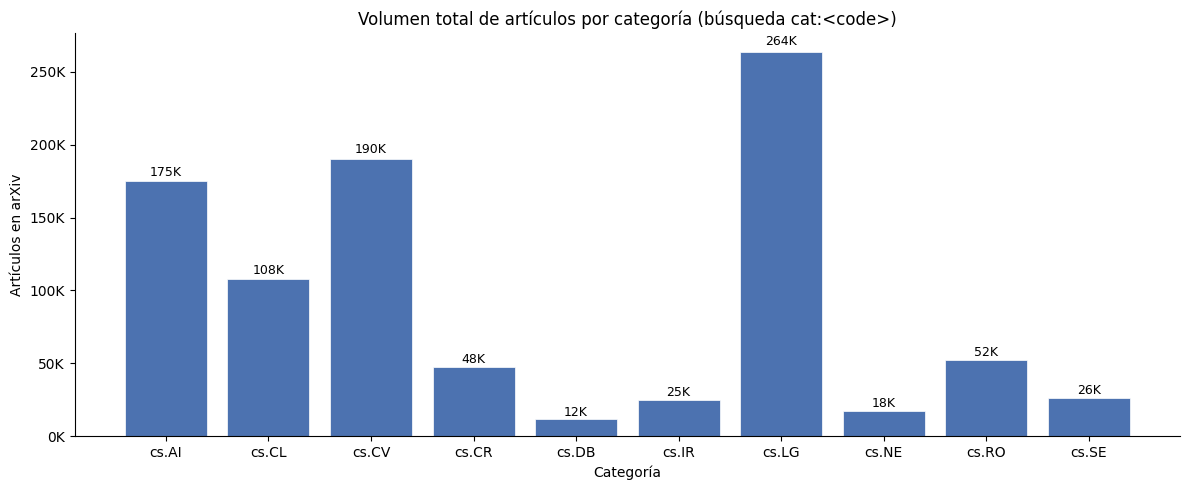

In [25]:
# Gráfico 1: volumen total de artículos por categoría en arXiv
codes  = [r['code']  for r in stats]
totals = [r['total'] for r in stats]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(codes, totals, color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Categoría')
ax.set_ylabel('Artículos en arXiv')
ax.set_title('Volumen total de artículos por categoría (búsqueda cat:<code>)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Anotar valores encima de cada barra
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{val/1000:.0f}K', ha='center', va='bottom', fontsize=9)

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

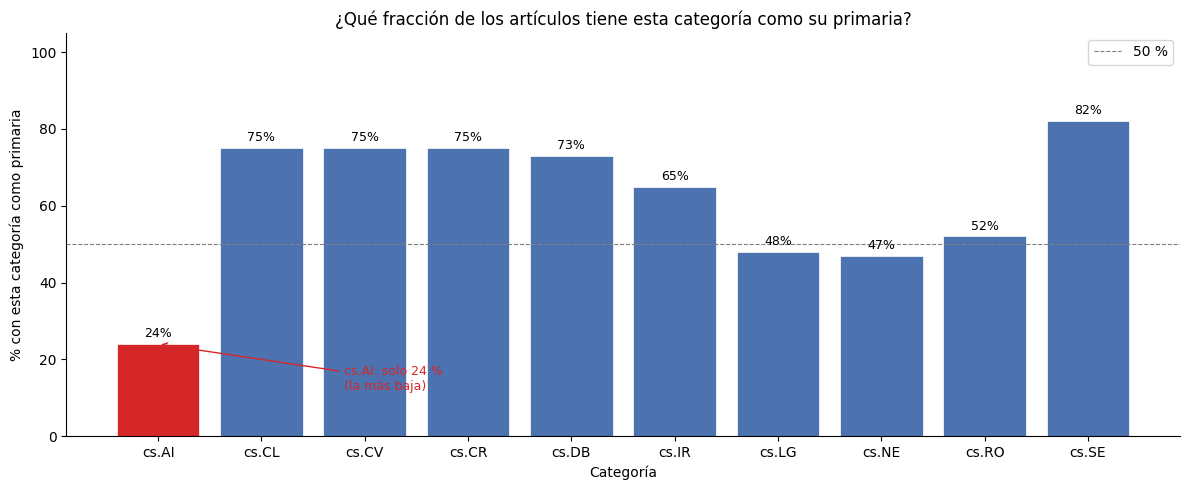

In [26]:
# Gráfico 2: porcentaje de artículos con esta categoría como primaria
primary_pcts = [r['primary_pct'] for r in stats]
# Resaltar cs.AI en rojo por ser el caso más extremo
colors = ['#d62728' if r['code'] == 'cs.AI' else '#4C72B0' for r in stats]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(codes, primary_pcts, color=colors, edgecolor='white', linewidth=0.5)

# Línea de referencia al 50 %
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50 %')
ax.set_xlabel('Categoría')
ax.set_ylabel('% con esta categoría como primaria')
ax.set_title('¿Qué fracción de los artículos tiene esta categoría como su primaria?')
ax.set_ylim(0, 105)

# Anotar porcentajes
for bar, val in zip(bars, primary_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

# Flecha que señala el caso extremo de cs.AI
ax.annotate('cs.AI: solo 24 %\n(la más baja)',
            xy=(0, 24), xytext=(1.8, 12),
            arrowprops=dict(arrowstyle='->', color='#d62728'),
            fontsize=9, color='#d62728')

ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4.3 Las 10 categorías seleccionadas y su justificación

| Código | Nombre | Justificación |
|--------|--------|---------------|
| `cs.AI` | Artificial Intelligence | Categoría "madre" histórica; solo 24 % primaria pero necesaria como referencia |
| `cs.CL` | Computation and Language | NLP y modelos de lenguaje; 75 % primaria, comunidad muy activa |
| `cs.CV` | Computer Vision | La más voluminosa (190 K+); 75 % primaria, bien delimitada semánticamente |
| `cs.CR` | Cryptography and Security | Dominio muy distinto al resto; actúa como "anclaje" de separación clara |
| `cs.DB` | Databases | Menor volumen (11 K) pero 73 % primaria; vocabulario muy específico |
| `cs.IR` | Information Retrieval | Recuperación, recomendación, ranking; 65 % primaria |
| `cs.LG` | Machine Learning | La más grande (263 K); 48 % primaria, solapamiento esperado con cs.AI y cs.NE |
| `cs.NE` | Neural and Evolutionary Computing | Redes neuronales y algoritmos evolutivos; 47 % primaria |
| `cs.RO` | Robotics | Robots y sistemas físicos; vocabulario diferente del resto |
| `cs.SE` | Software Engineering | Código, testing, herramientas; 82 % primaria — la etiqueta más "limpia" |

**Solapamiento esperado en los errores del modelo:**  
cs.AI, cs.LG y cs.NE son las tres categorías con mayor solapamiento semántico. Un paper de redes neuronales profundas puede etiquetarse en cualquiera de las tres dependiendo de quién lo escribe. Los errores del clasificador en estas tres clases no serán un fallo del modelo — serán un reflejo de la ambigüedad real en los datos.

> **Punto clave para recordar:** elegir categorías basándose en datos revela que intuiciones razonables ("cs.AI es la categoría central de la IA") son engañosas. El solapamiento entre cs.AI, cs.LG y cs.NE es real, anticipado, y aparecerá en los errores del modelo como algo esperado, no como un problema a resolver.

## Sección 5 — El dataset resultante

Antes de ver el código, es importante entender qué contiene el dataset:

- **2 000 artículos** en total, **200 por categoría** — perfectamente balanceado
- Cada artículo tiene: ID de arXiv, título, abstract (desde la API), categoría primaria,   todas las categorías, fecha de publicación, URL del PDF
- Los artículos son los **más recientes disponibles** en cada categoría (ordenados por fecha descendente en la API)

Total de artículos: 2000
Categorías: ['cs.AI', 'cs.CL', 'cs.CR', 'cs.CV', 'cs.DB', 'cs.IR', 'cs.LG', 'cs.NE', 'cs.RO', 'cs.SE']

Categoría      N artículos  Palabras (media)  Palabras (mediana)
-----------------------------------------------------------------
cs.AI                  200               191                 194
cs.CL                  200               180                 178
cs.CR                  200               194                 198
cs.CV                  200               187                 188
cs.DB                  200               188                 193
cs.IR                  200               194                 193
cs.LG                  200               183                 183
cs.NE                  200               180                 181
cs.RO                  200               180                 181
cs.SE                  200               196                 204


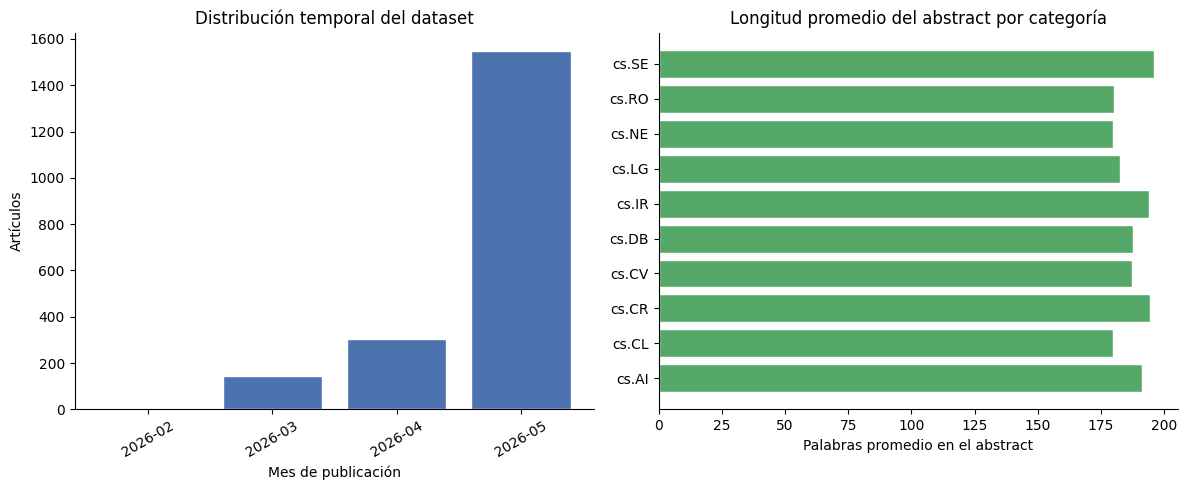

In [27]:
# Estadísticas del dataset: artículos por categoría, longitud de abstracts, distribución temporal
metadata = json.loads((ROOT / "data/raw/metadata.json").read_text(encoding="utf-8"))

# Agrupar por categoría
by_cat = {}
for r in metadata:
    by_cat.setdefault(r['primary_category'], []).append(r)

print(f"Total de artículos: {len(metadata)}")
print(f"Categorías: {sorted(by_cat.keys())}\n")

# Tabla de longitud de abstracts
print(f"{'Categoría':<12}  {'N artículos':>12}  {'Palabras (media)':>16}  {'Palabras (mediana)':>18}")
print("-" * 65)
for cat in sorted(by_cat.keys()):
    lengths = [len(a['abstract_api'].split()) for a in by_cat[cat]]
    print(f"{cat:<12}  {len(by_cat[cat]):>12}  {mean(lengths):>16.0f}  {median(lengths):>18.0f}")

# Distribución temporal (por mes)
months = Counter(r['published'][:7] for r in metadata)
sorted_months = sorted(months.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma por mes de publicación
ax = axes[0]
ax.bar(sorted_months, [months[m] for m in sorted_months],
       color='#4C72B0', edgecolor='white')
ax.set_xlabel('Mes de publicación')
ax.set_ylabel('Artículos')
ax.set_title('Distribución temporal del dataset')
ax.spines[['top', 'right']].set_visible(False)
for label in ax.get_xticklabels():
    label.set_rotation(30)

# Longitud promedio de abstract por categoría
ax2 = axes[1]
cat_names   = sorted(by_cat.keys())
mean_lengths = [mean(len(a['abstract_api'].split()) for a in by_cat[c]) for c in cat_names]
ax2.barh(cat_names, mean_lengths, color='#55A868', edgecolor='white')
ax2.set_xlabel('Palabras promedio en el abstract')
ax2.set_title('Longitud promedio del abstract por categoría')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [28]:
# Mostrar 3 registros reales de categorías semánticamente muy distintas
sample_categories = ['cs.CV', 'cs.CR', 'cs.SE']  # visión, seguridad, ingeniería de software

for cat in sample_categories:
    article = next(a for a in metadata if a['primary_category'] == cat)
    print('=' * 70)
    print(f"Categoría: {cat}")
    print(f"ID:        {article['arxiv_id']}")
    print(f"Título:    {article['title']}")
    print(f"Abstract:  {article['abstract_api'][:300]}...")
    print()

Categoría: cs.CV
ID:        2605.12501
Título:    Covering Human Action Space for Computer Use: Data Synthesis and Benchmark
Abstract:  Computer-use agents (CUAs) automate on-screen work, as illustrated by GPT-5.4 and Claude. Yet their reliability on complex, low-frequency interactions is still poor, limiting user trust. Our analysis of failure cases from advanced models suggests a long-tail pattern in GUI operations, where a relati...

Categoría: cs.CR
ID:        2605.12456
Título:    TextSeal: A Localized LLM Watermark for Provenance & Distillation Protection
Abstract:  We introduce TextSeal, a state-of-the-art watermark for large language models. Building on Gumbel-max sampling, TextSeal introduces dual-key generation to restore output diversity, along with entropy-weighted scoring and multi-region localization for improved detection. It supports serving optimizat...

Categoría: cs.SE
ID:        2605.12280
Título:    Iterative Audit Convergence in LLM-Managed Multi-Agent Systems: A 

> **Punto clave para recordar:** el dataset tiene 2 000 artículos perfectamente balanceados (200 por clase). Este balance es una decisión de diseño deliberada que simplifica el entrenamiento inicial — en producción, las distribuciones reales son mucho más desiguales.

## Sección 6 — Verificaciones por etapa

### 6.1 Criterios de aceptación por etapa

| Etapa | Criterio de aceptación |
|-------|------------------------|
| 1. Exploración | `categories_stats.json` existe, todas las entradas tienen `total > 0` |
| 2. Selección | `categories.json` tiene exactamente 10 entradas con campos `code`, `name`, `n_per_class` |
| 3. Metadata | `metadata.json` tiene exactamente 200 artículos por categoría, sin duplicados |
| 4. PDFs | Al menos 95 % de PDFs descargados exitosamente |
| 5. Extracción | `extracted_*.json` existen; tasa de éxito ≥ 90 % por librería |
| 6. Estrategia | `extracted.json` existe; similitud coseno promedio ≥ 0.80 con la librería elegida |
| 7. Dataset | Splits train/val/test sin leakage de IDs entre splits |
| 8. Entrenamiento | Accuracy macro-promedio ≥ 0.70 en el test set |

### 6.2 Por qué verificar en cada etapa y no solo al final

En un pipeline lineal, los errores se propagan silenciosamente.

**Ejemplo real:** si `download_metadata.py` descarga 180 artículos de cs.AI en lugar de 200 (porque la API paginó mal), el dataset quedará ligeramente desbalanceado. El modelo mostrará métricas "normales" en general pero con cs.AI levemente peor — y solo lo descubriríamos analizando las métricas por clase al final.

El patrón correcto es: **verificar → avanzar → verificar → avanzar**.  
Cada etapa produce un artefacto verificable antes de pasar a la siguiente.

In [29]:
# Verificación en vivo: estado actual del proyecto

def check(path, label, detail_fn=None):
    exists = Path(path).exists()
    size   = f"{Path(path).stat().st_size / 1024:.1f} KB" if exists else "-"
    detail = ""
    if exists and detail_fn:
        try:
            detail = detail_fn(path)
        except Exception as e:
            detail = f"ERROR: {e}"
    mark = "✓" if exists else "✗"
    print(f"  {mark}  {label:<45}  {size:>10}  {detail}")

print("Estado del pipeline\n" + "=" * 80)

print("\nEtapas 1-2 — Configuración:")
check(ROOT / "data/results/categories_stats.json", "categories_stats.json",
      lambda p: f"{len(json.loads(Path(p).read_text()))} categorías")
check(ROOT / "configs/categories.json", "categories.json",
      lambda p: f"{len(json.loads(Path(p).read_text()))} categorías")
check(ROOT / "reports/category_exploration.csv", "category_exploration.csv",
      lambda p: f"{sum(1 for _ in open(p)) - 1} filas")

print("\nEtapa 3 — Metadata:")
check(ROOT / "data/raw/metadata.json", "metadata.json",
      lambda p: f"{len(json.loads(Path(p).read_text()))} artículos")

print("\nEtapa 4 — PDFs:")
pdf_dir = ROOT / "data" / "pdfs"
if pdf_dir.exists():
    pdfs = list(pdf_dir.rglob("*.pdf"))
    total_mb = sum(p.stat().st_size for p in pdfs) / 1024 / 1024
    print(f"  ✓  {'data/pdfs/':<45}  {total_mb:>7.1f} MB  {len(pdfs)} archivos")
else:
    print(f"  ✗  {'data/pdfs/ (no existe)':<45}")

print("\nEtapas 5-6 — Extracción y selección:")
check(ROOT / "data/interim/extracted_pymupdf.json", "extracted_pymupdf.json",
      lambda p: f"{len(json.loads(Path(p).read_text()))} registros")
check(ROOT / "data/interim/extracted_docling.json", "extracted_docling.json",
      lambda p: f"{len(json.loads(Path(p).read_text()))} registros")
check(ROOT / "data/interim/extracted.json", "extracted.json",
      lambda p: f"{len(json.loads(Path(p).read_text()))} registros")

print("\nEtapa 6 — Embeddings:")
emb_dir = ROOT / "data" / "interim" / "embeddings"
for fname in ["abstract_api.npy", "abstract_pymupdf.npy", "abstract_docling.npy", "arxiv_ids.json"]:
    check(emb_dir / fname, f"embeddings/{fname}")

print("\nEtapas 7-8 — Dataset y modelo:")
print(f"  -  {'(pendientes — próximos notebooks)':<45}")

Estado del pipeline

Etapas 1-2 — Configuración:
  ✓  categories_stats.json                              1.1 KB  10 categorías
  ✓  categories.json                                    0.8 KB  10 categorías
  ✓  category_exploration.csv                           0.4 KB  10 filas

Etapa 3 — Metadata:
  ✓  metadata.json                                   3438.3 KB  2000 artículos

Etapa 4 — PDFs:
  ✓  data/pdfs/                                      7878.0 MB  2000 archivos

Etapas 5-6 — Extracción y selección:
  ✓  extracted_pymupdf.json                          3854.5 KB  2000 registros
  ✓  extracted_docling.json                          3953.9 KB  2000 registros
  ✓  extracted.json                                  9659.6 KB  2000 registros

Etapa 6 — Embeddings:
  ✓  embeddings/abstract_api.npy                     3000.1 KB  
  ✓  embeddings/abstract_pymupdf.npy                 3000.1 KB  
  ✓  embeddings/abstract_docling.npy                 3000.1 KB  
  ✓  embeddings/arxiv_ids.json    

> **Punto clave para recordar:** las etapas 1–6 del pipeline están completas. Los artefactos en disco permiten verificar el estado exacto del proyecto en cualquier momento. Los próximos notebooks cubren la construcción del dataset y el entrenamiento del clasificador.